# 零售销量预测与库存决策
先运行 `run_analysis.py`，再依次阅读。核心实现保留在 src 中。

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
if not (root / 'config.json').exists():
    root = root.parent
assert (root / 'config.json').exists()

## 1. 商品样本
只在训练期按活跃度和销售额选样本。思考：用全时期选择会造成什么偏差？

,product_id,revenue,active_weeks,description,active_share,mean,std,cv
0,22423,238235.15,65,REGENCY CAKESTAND 3 TIER,0.8125,235.2125,230.705670,0.980839
1,85123A,199404.04,78,WHITE HANGING HEART T-LIGHT HOLDER,0.9750,913.3000,603.750250,0.661065
2,85099B,116000.83,78,JUMBO BAG RED WHITE SPOTTY,0.9750,791.3750,456.006645,0.576221
3,47566,98674.76,77,PARTY BUNTING,0.9625,236.2375,236.667007,1.001818
4,84879,87474.89,78,ASSORTED COLOUR BIRD ORNAMENT,0.9750,672.0000,703.479490,1.046844


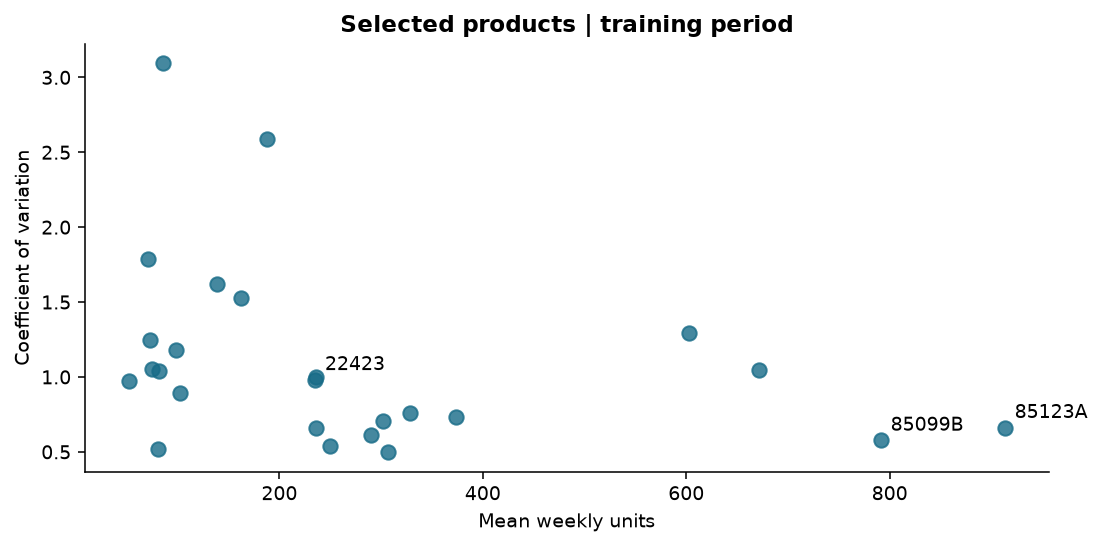

In [2]:
products = pd.read_csv(root / 'outputs/tables/selected_products.csv')
display(products.head())
display(Image(filename=str(root / 'outputs/figures/03_volatility.png')))

## 2. 预测
比较验证和测试，查看移动平均与岭回归能否稳定超越朴素规则。

,split,model,mae,wape,macro_mae
0,test,moving_average,160.645833,0.487924,160.645833
1,test,naive,203.310000,0.617507,203.310000
2,test,ridge,163.249376,0.495832,163.249376
3,validation,moving_average,142.020000,0.576325,142.020000
4,validation,naive,157.883333,0.640700,157.883333
5,validation,ridge,142.810141,0.579532,142.810141


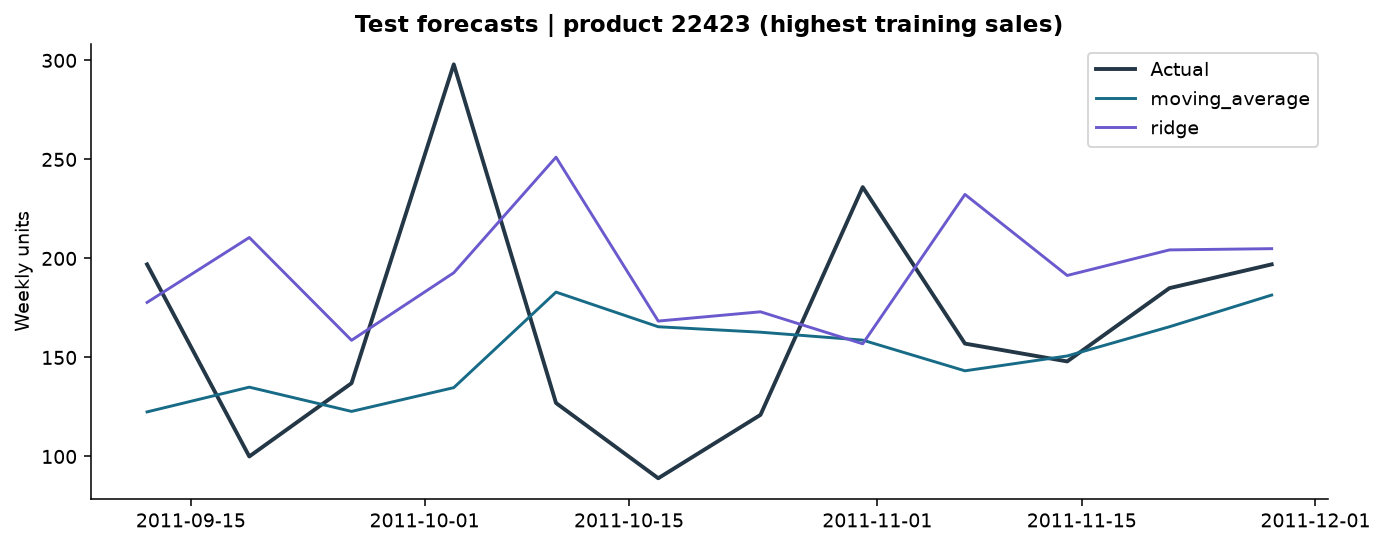

In [3]:
scores = pd.read_csv(root / 'outputs/tables/forecast_metrics.csv')
display(scores)
display(Image(filename=str(root / 'outputs/figures/04_forecast.png')))

## 3. 补货决策
C 在验证期选择，测试期不重新选择。成本为假设单位，不是实际利润。

,split,model,lead,factor,penalty,mean_inventory,shortage,fill_rate,cost,policy
3,test,moving_average,0,1.0,5,184.833333,15671.0,0.841343,133805.0,A
4,test,ridge,0,1.0,5,177.000000,18303.0,0.814696,144615.0,B
5,test,ridge,0,0.5,5,113.030000,24133.0,0.755672,154574.0,C


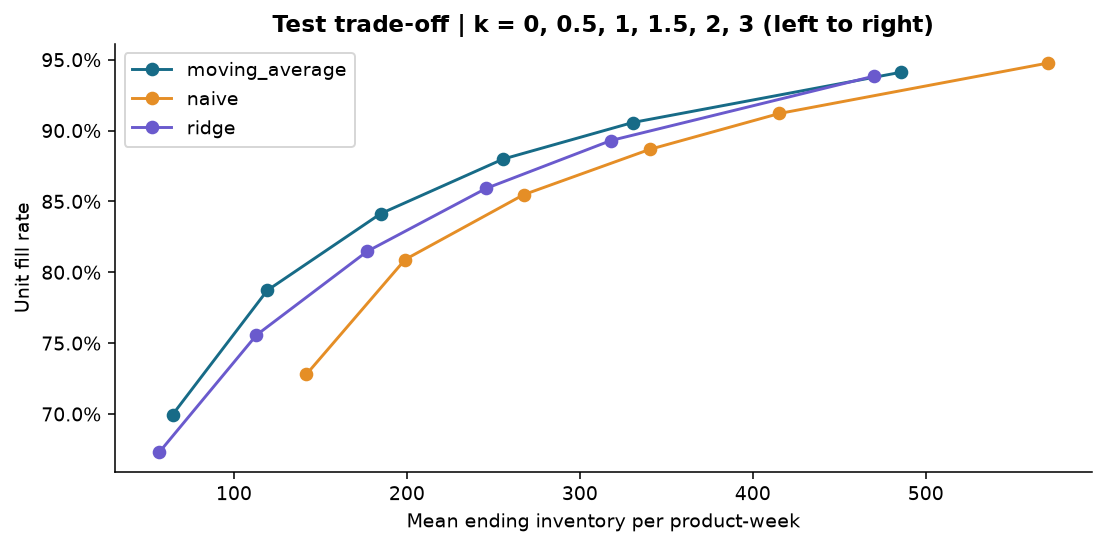

In [4]:
policies = pd.read_csv(root / 'outputs/tables/policy_comparison.csv')
display(policies.query('lead == 0 and penalty == 5'))
display(Image(filename=str(root / 'outputs/figures/07_tradeoff.png')))

## 4. 手工检查库存守恒
可用库存 − 满足需求 = 期末库存；需求 = 满足量 + 缺货量。

In [5]:
trace = pd.read_csv(root / 'outputs/tables/inventory_traces.csv')
example = trace.query("split == 'test' and model == 'moving_average' and factor == 1 and lead == 0")
display(example.head(8))
assert ((trace.opening + trace.arrivals - trace.fulfilled - trace.ending).abs() < 1e-8).all()

,week,product_id,actual,opening,arrivals,order,fulfilled,shortage,ending,on_order,split,model,lead,factor
600,2011-09-12,15056N,112.0,0.0,192.0,192.0,112.0,0.0,80.0,0.0,test,moving_average,0,1.0
601,2011-09-19,15056N,26.0,80.0,107.0,107.0,26.0,0.0,161.0,0.0,test,moving_average,0,1.0
602,2011-09-26,15056N,46.0,161.0,0.0,0.0,46.0,0.0,115.0,0.0,test,moving_average,0,1.0
603,2011-10-03,15056N,22.0,115.0,48.0,48.0,22.0,0.0,141.0,0.0,test,moving_average,0,1.0
604,2011-10-10,15056N,29.0,141.0,4.0,4.0,29.0,0.0,116.0,0.0,test,moving_average,0,1.0
605,2011-10-17,15056N,17.0,116.0,9.0,9.0,17.0,0.0,108.0,0.0,test,moving_average,0,1.0
606,2011-10-24,15056N,105.0,108.0,14.0,14.0,105.0,0.0,17.0,0.0,test,moving_average,0,1.0
607,2011-10-31,15056N,6.0,17.0,120.0,120.0,6.0,0.0,131.0,0.0,test,moving_average,0,1.0


## 5. 讨论
1. 为什么成本最优方案未必有最低 MAE？
2. 验证选择是否在测试期保持优势？
3. 没有实际库存，结论能推广到哪里？

完整回答及实际结论见 docs/analysis_report.md。